In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer

In [3]:
#Read data

df = pd.read_csv("train (Copy).csv")

In [4]:
#Explore data

print(df.head())
print("-----------------------")
print(df.tail())
print("-----------------------")
print(df.sample(5))
print("-----------------------")
print(df.describe())
print("-----------------------")
print(df.info())
print(df.shape)

   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    NaN   NaN         NaN       0     12   

  YrSold  SaleType  SaleCondition  SalePrice  
0   2008        WD   

In [5]:
for col in df.columns:
    if df[col].nunique() == len(df):
        print(f"Column'{col}' is unique for every row")

Column'Id' is unique for every row


In [6]:
if 'Id' in df.columns:
    df.drop(columns=['Id'], inplace=True)

print("-----------------------")
print(df.shape)

-----------------------
(1460, 80)


In [7]:
numerical_cols = df.select_dtypes(include=[np.float64, np.int64]).columns.tolist()
numerical_cols

['MSSubClass',
 'LotFrontage',
 'LotArea',
 'OverallQual',
 'OverallCond',
 'YearBuilt',
 'YearRemodAdd',
 'MasVnrArea',
 'BsmtFinSF1',
 'BsmtFinSF2',
 'BsmtUnfSF',
 'TotalBsmtSF',
 '1stFlrSF',
 '2ndFlrSF',
 'LowQualFinSF',
 'GrLivArea',
 'BsmtFullBath',
 'BsmtHalfBath',
 'FullBath',
 'HalfBath',
 'BedroomAbvGr',
 'KitchenAbvGr',
 'TotRmsAbvGrd',
 'Fireplaces',
 'GarageYrBlt',
 'GarageCars',
 'GarageArea',
 'WoodDeckSF',
 'OpenPorchSF',
 'EnclosedPorch',
 '3SsnPorch',
 'ScreenPorch',
 'PoolArea',
 'MiscVal',
 'MoSold',
 'YrSold',
 'SalePrice']

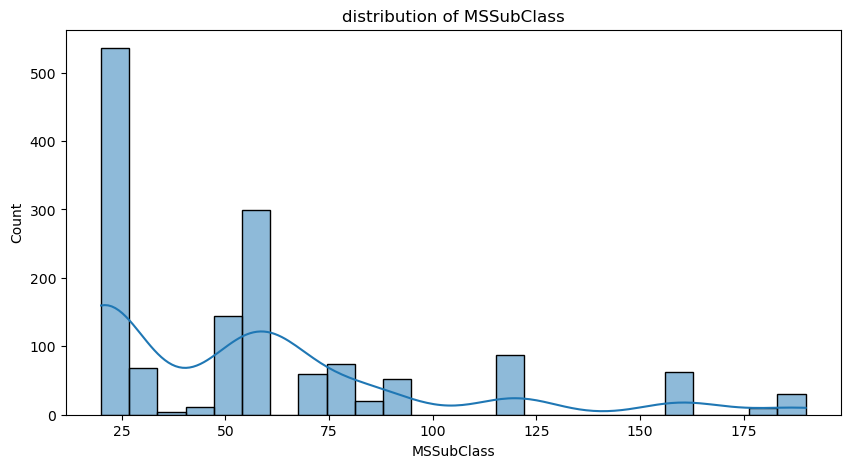

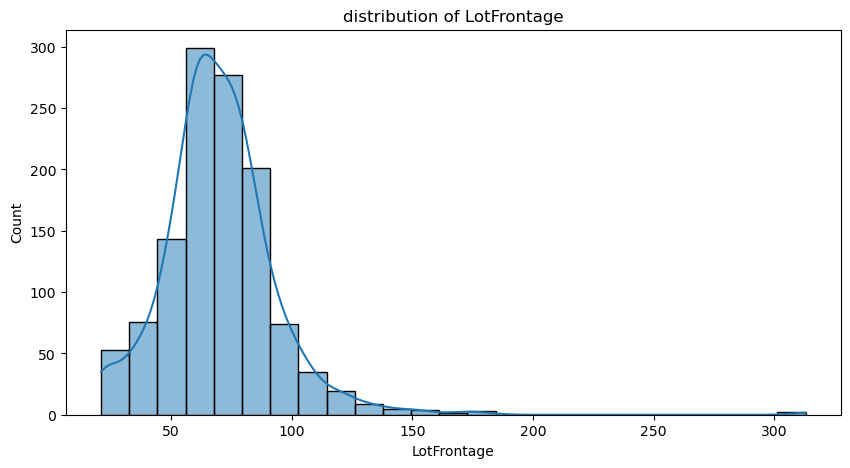

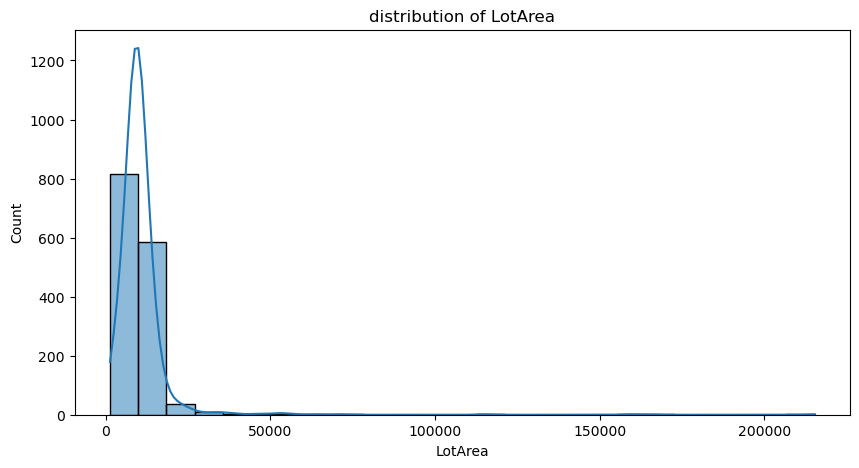

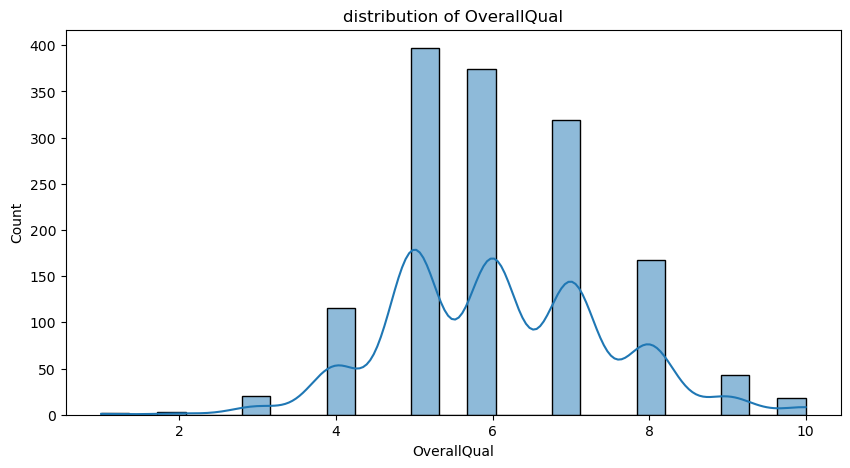

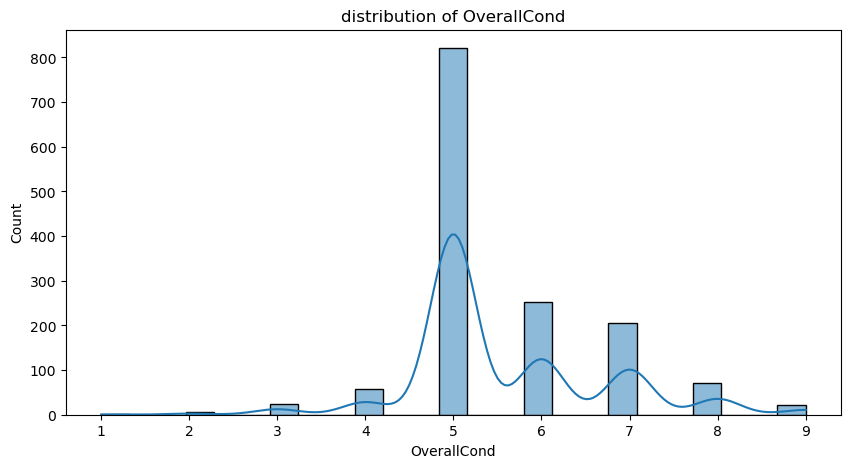

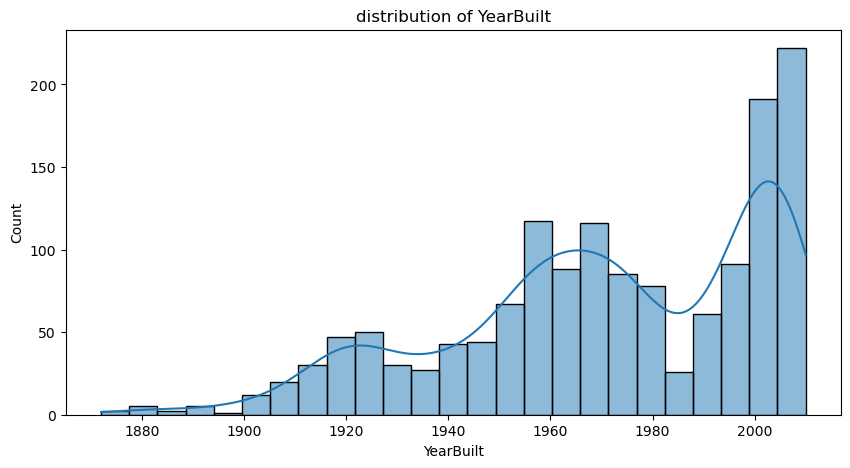

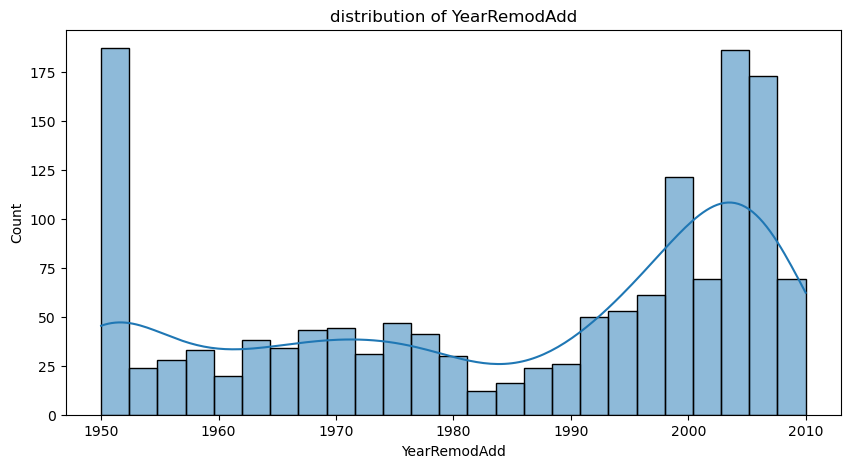

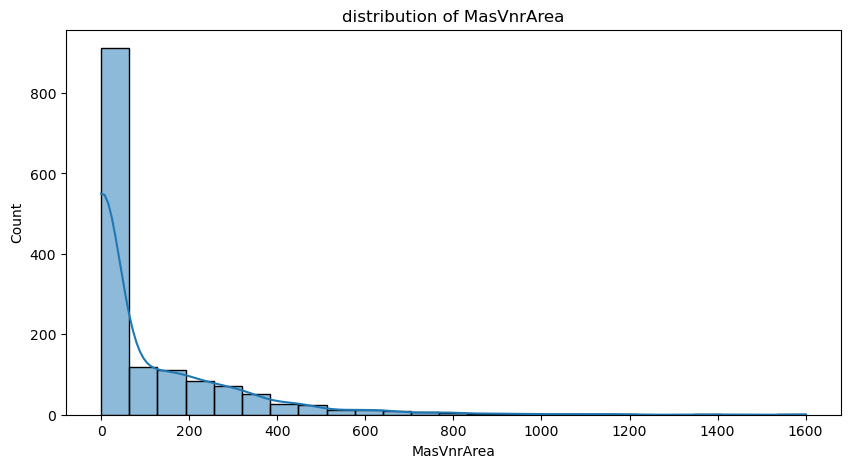

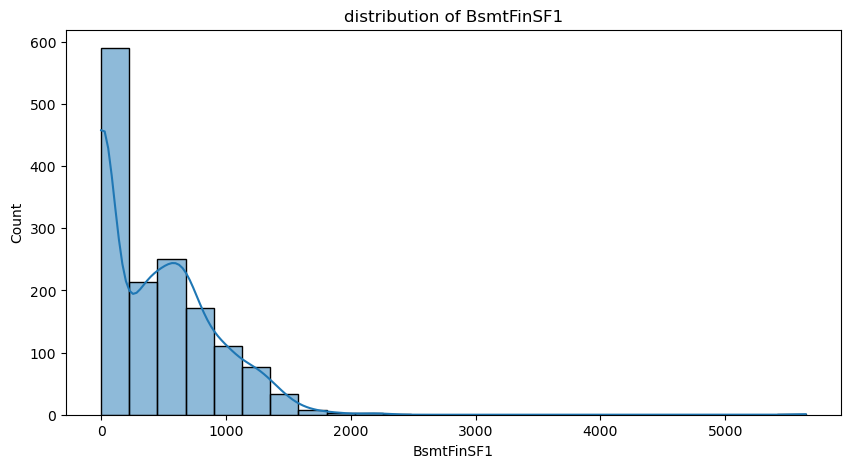

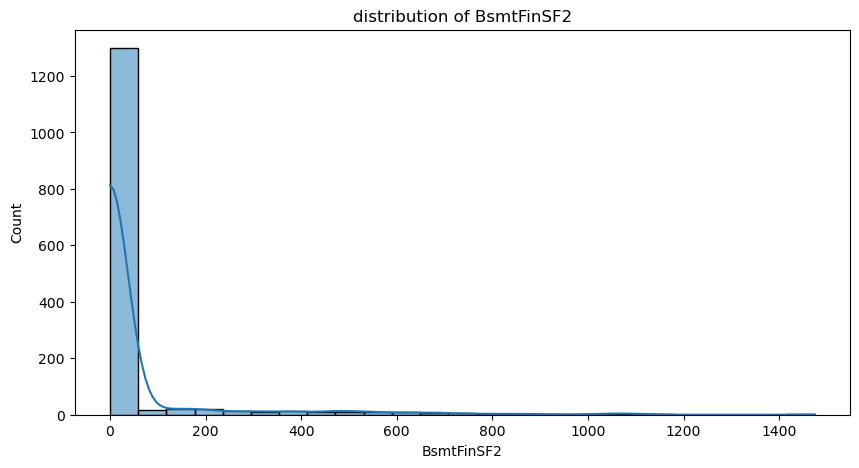

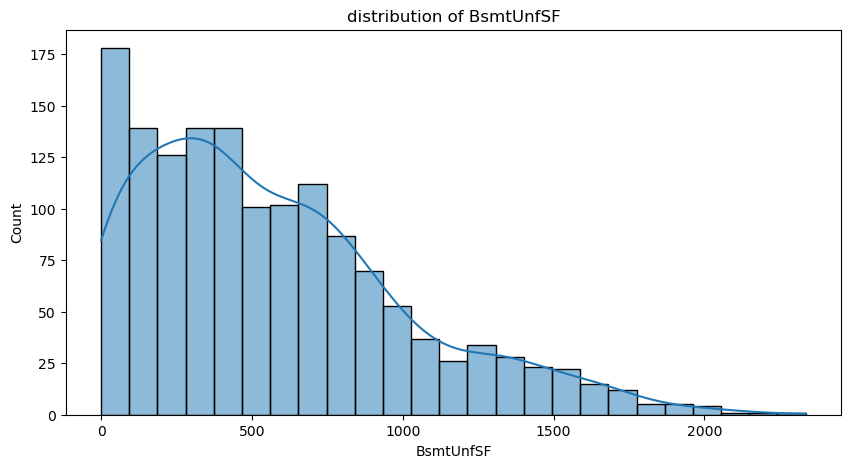

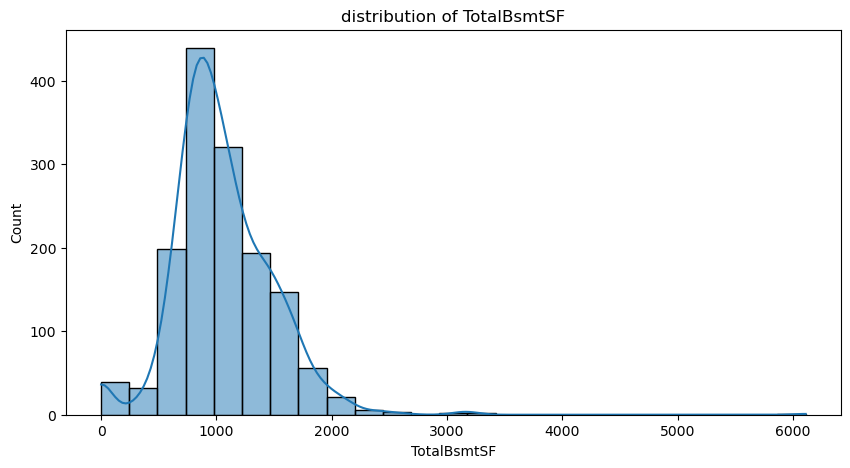

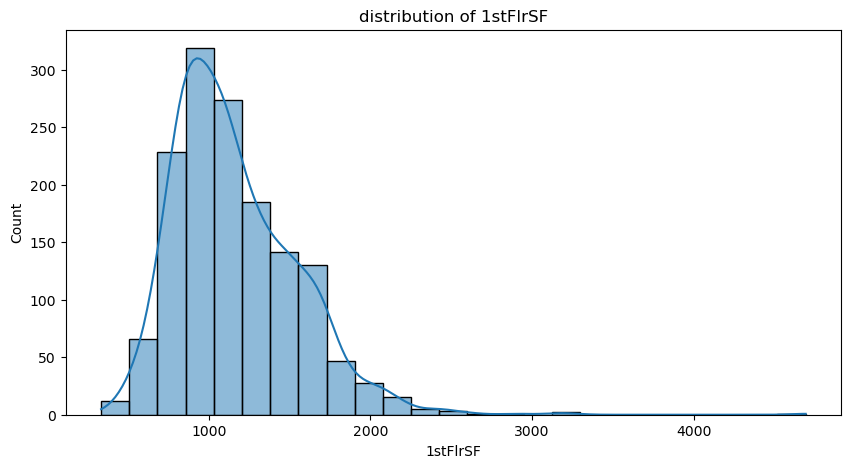

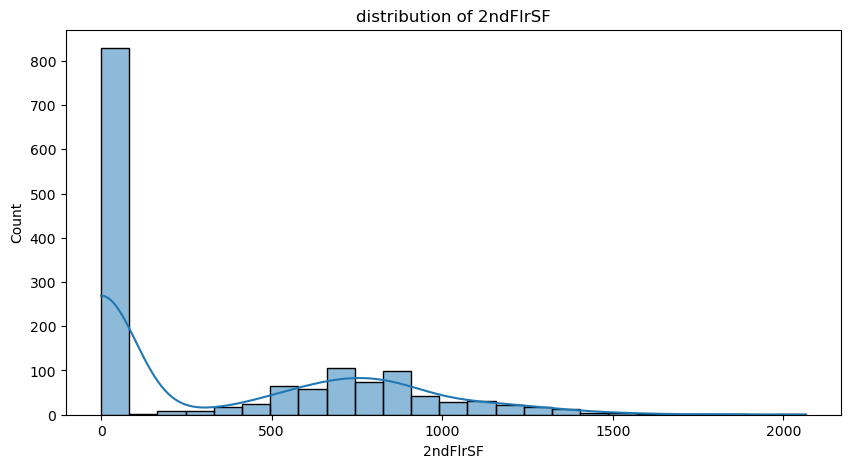

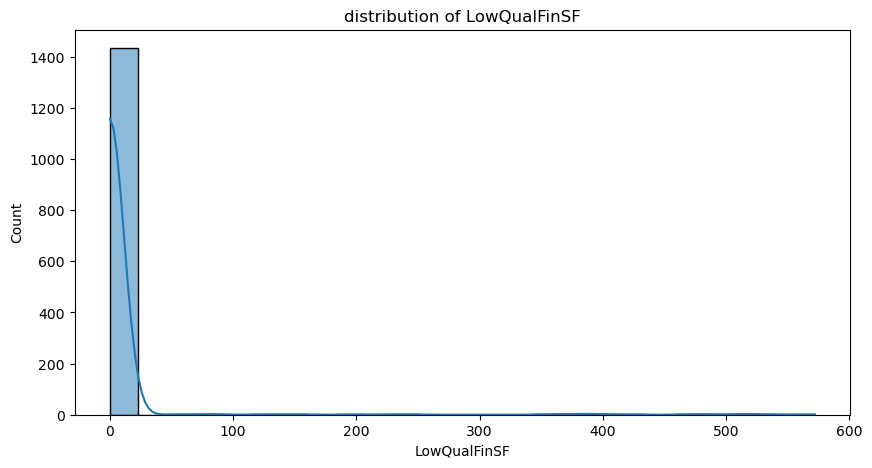

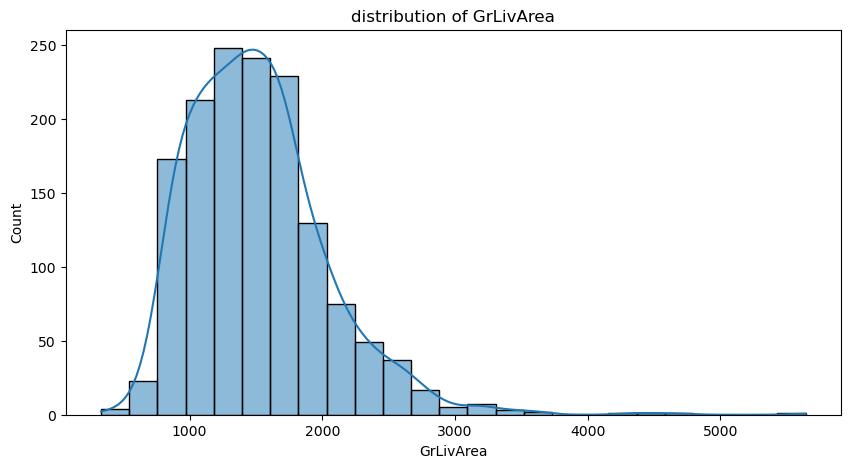

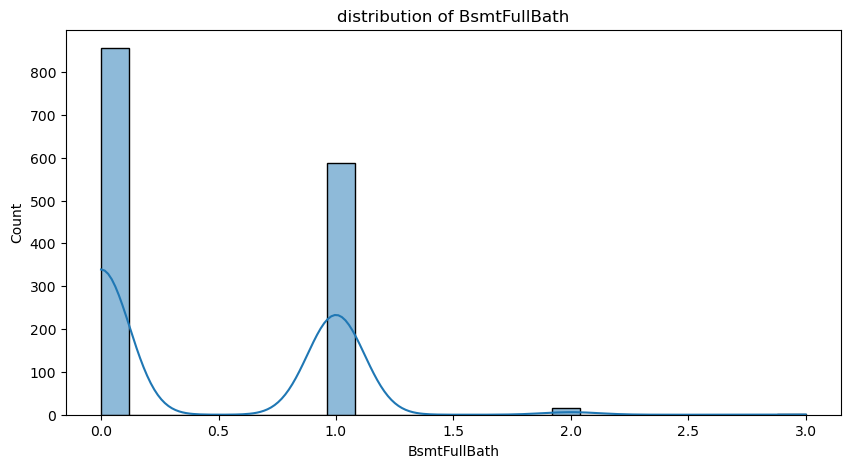

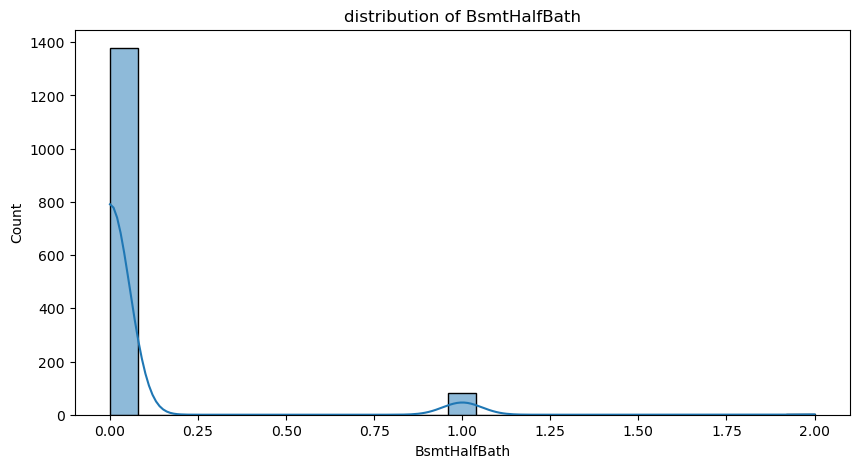

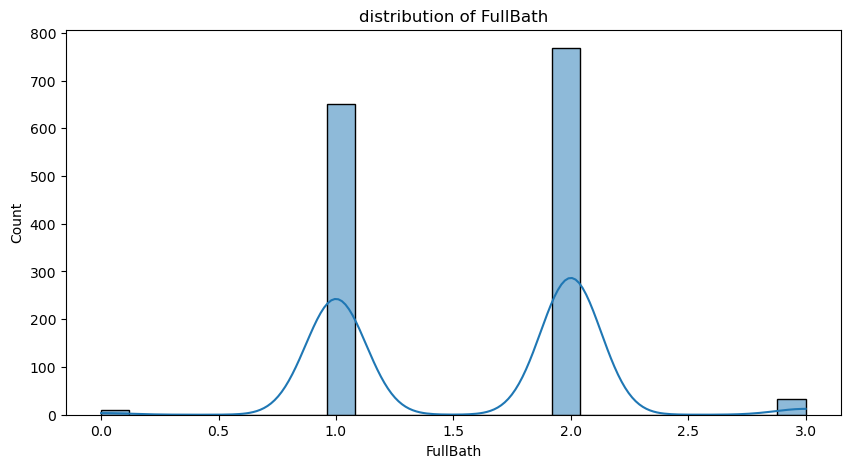

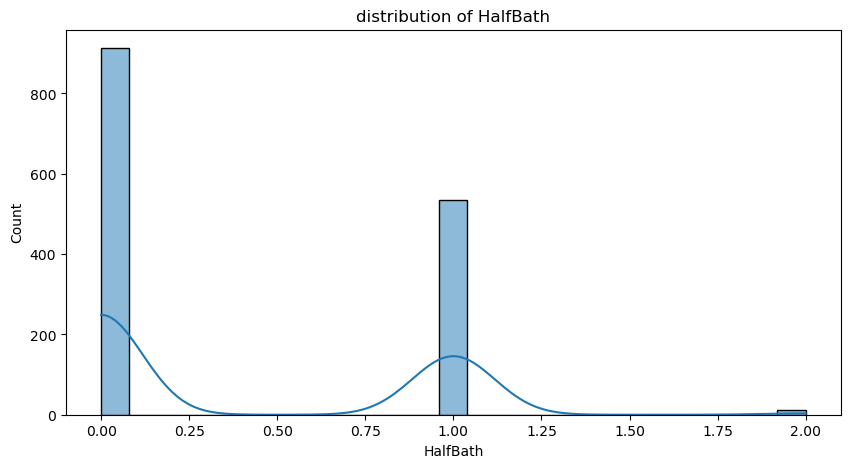

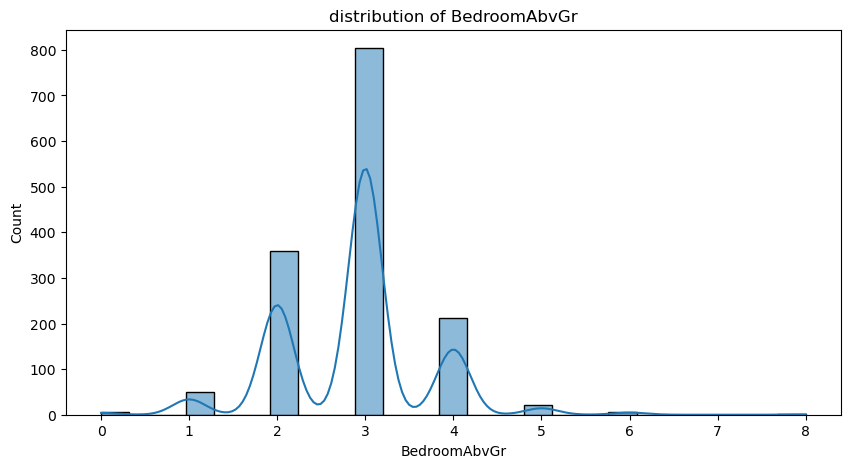

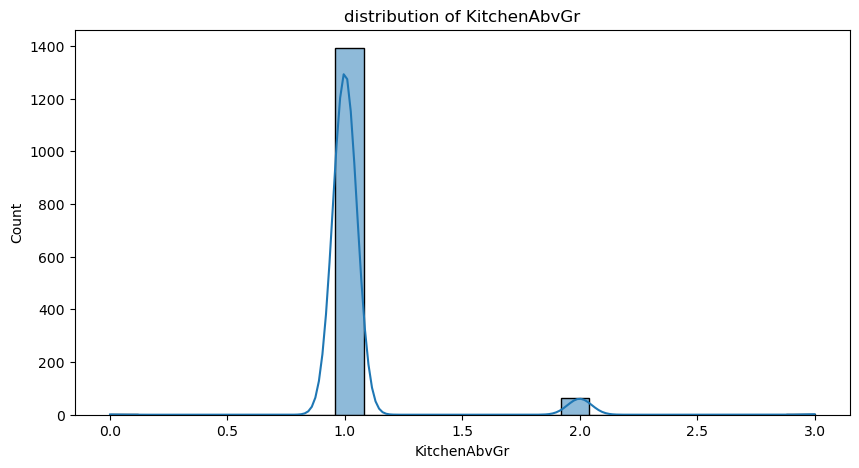

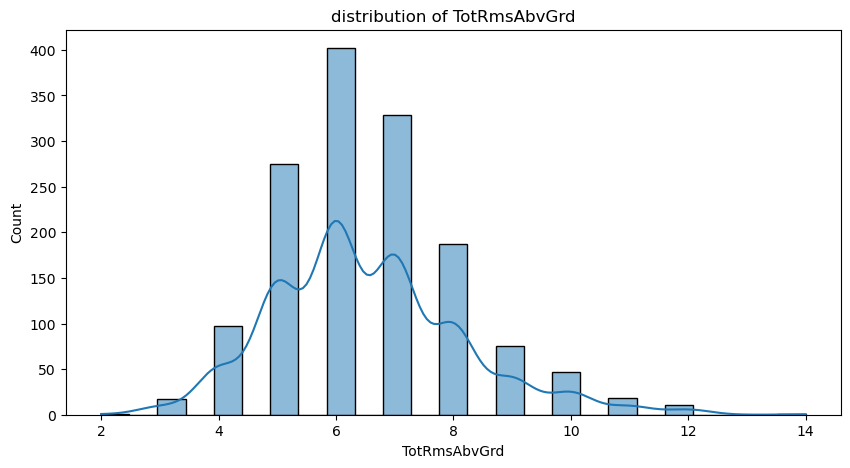

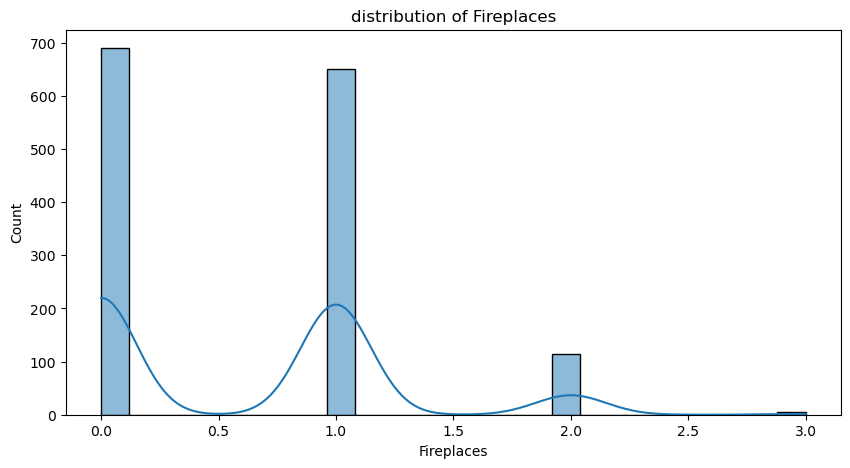

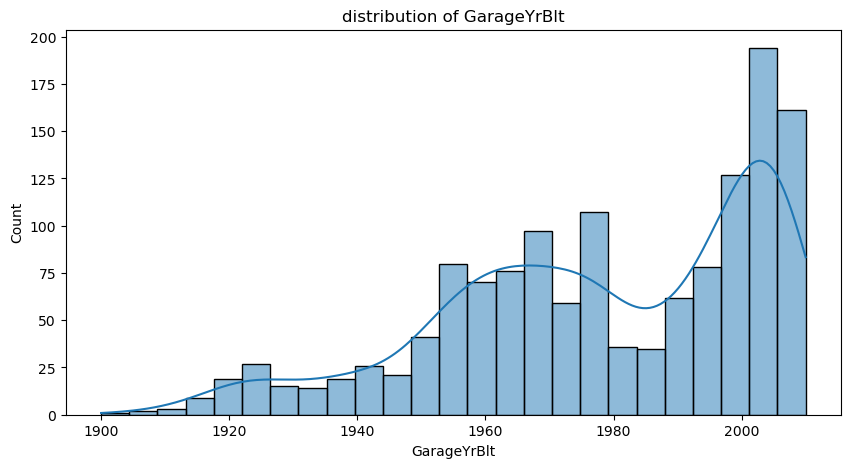

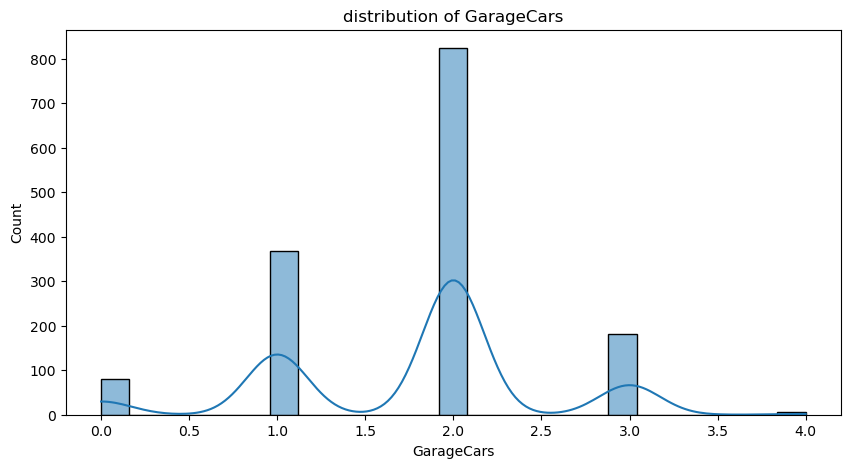

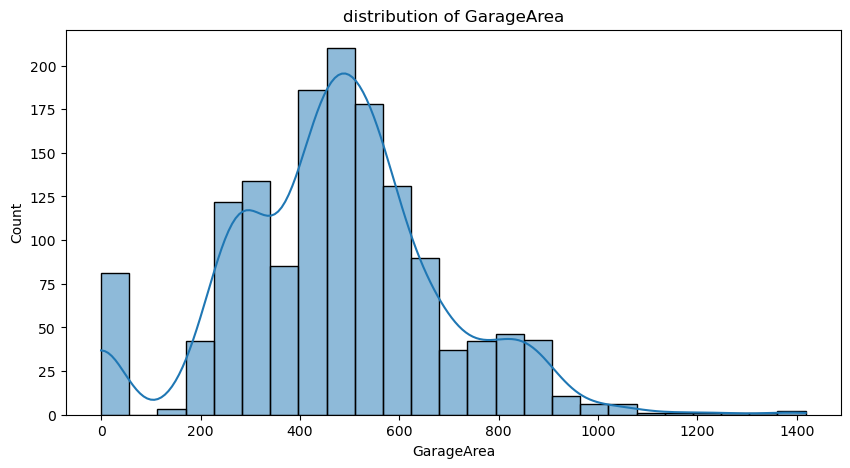

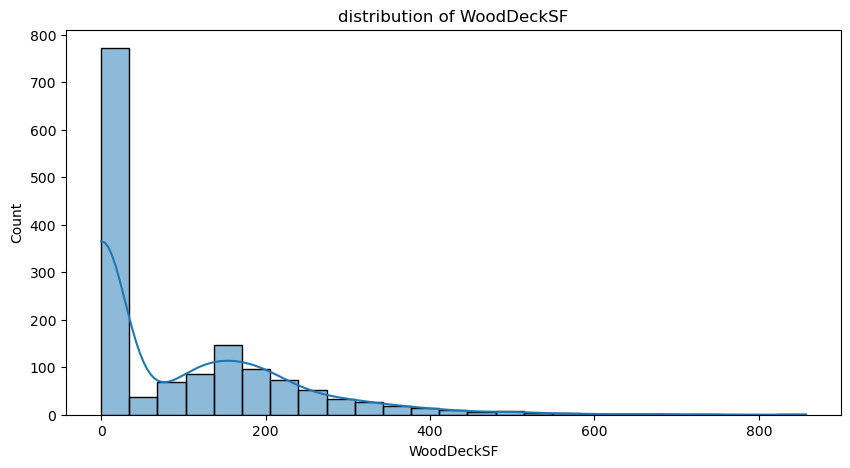

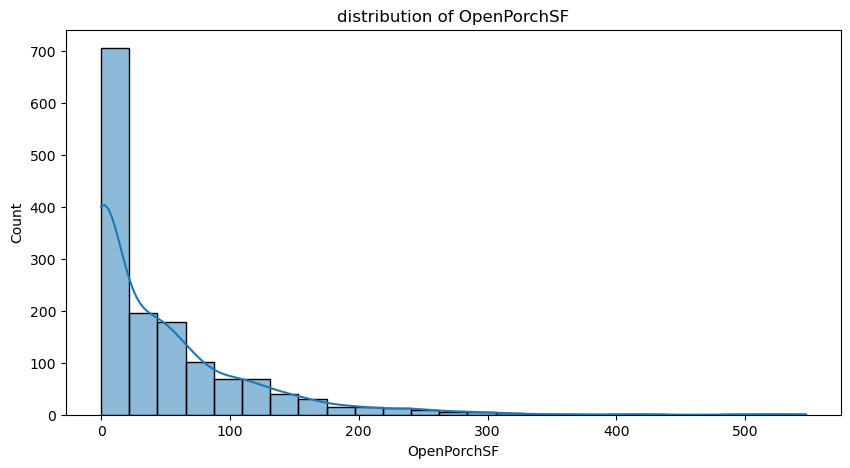

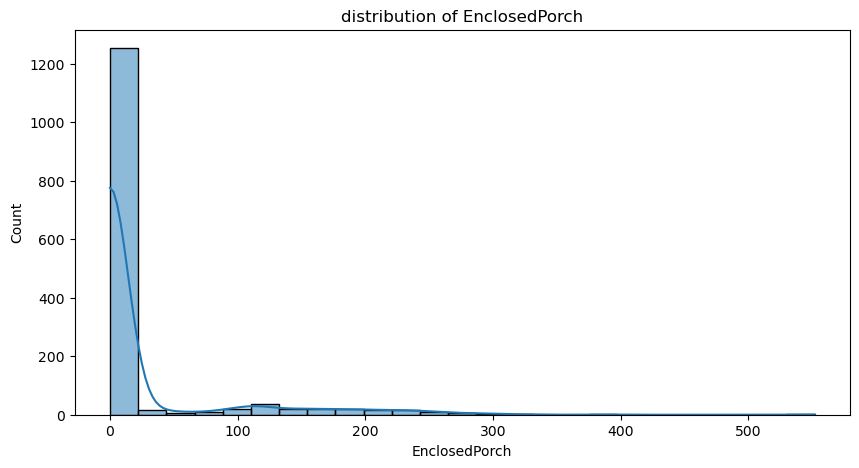

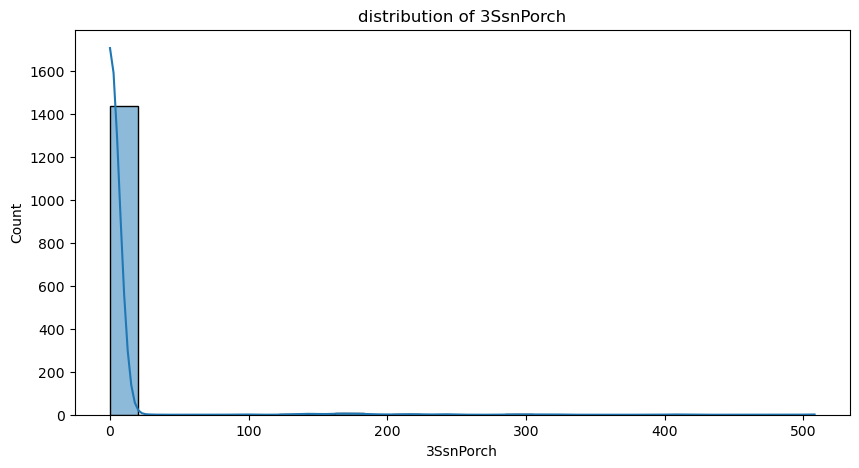

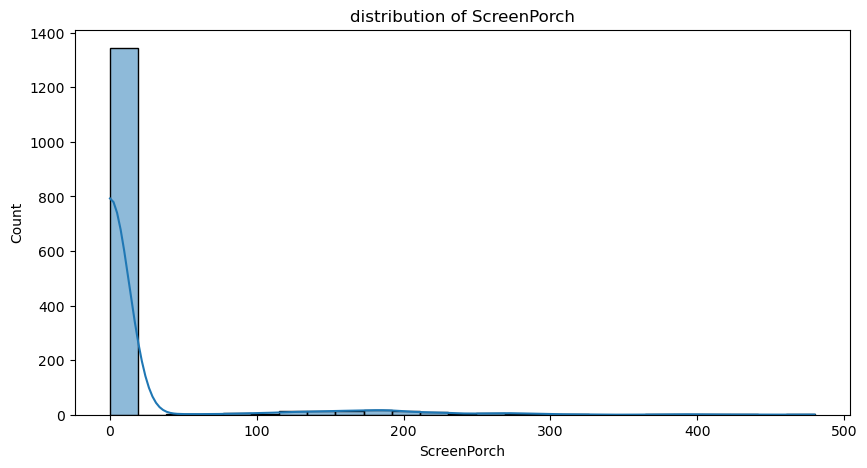

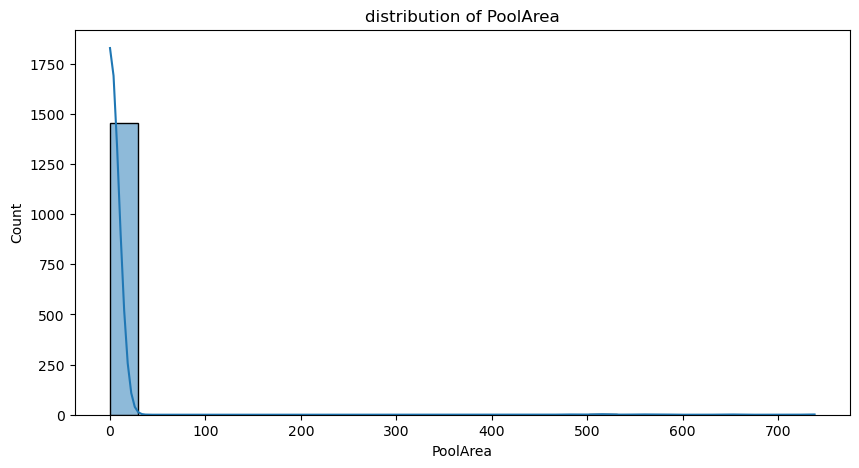

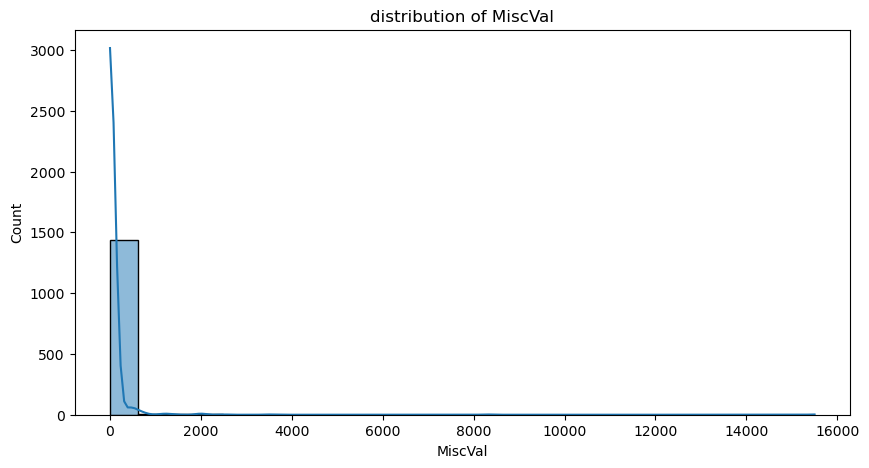

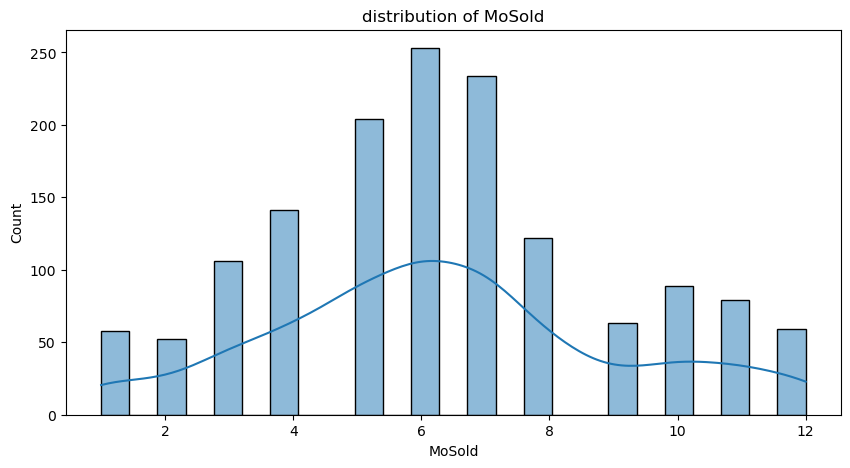

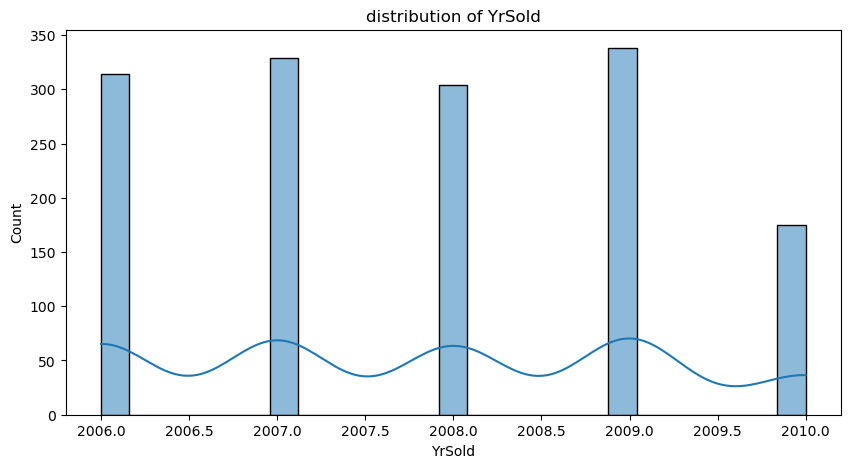

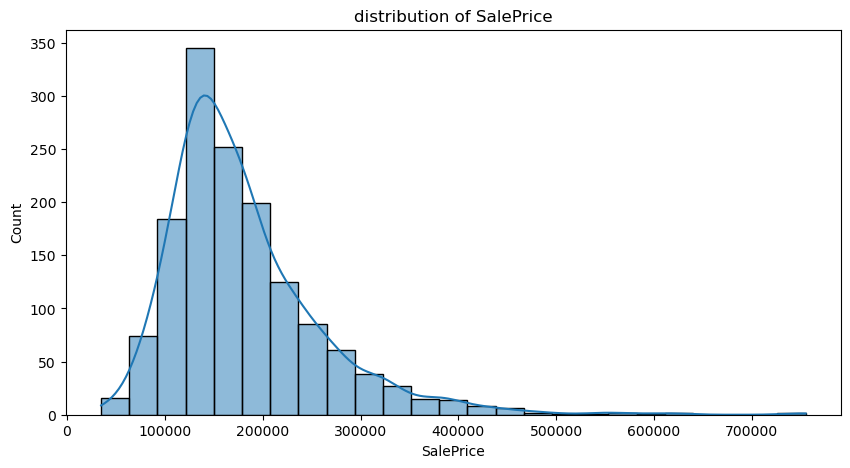

In [8]:
for col in numerical_cols:
    plt.figure(figsize=(10, 5))
    sns.histplot(df[col], kde=True ,bins=25)
    plt.title(f"distribution of {col}")
    plt.show()

In [9]:
for col in numerical_cols:
    print(f"nunique in '{col}'= {df[col].nunique()}")

nunique in 'MSSubClass'= 15
nunique in 'LotFrontage'= 110
nunique in 'LotArea'= 1073
nunique in 'OverallQual'= 10
nunique in 'OverallCond'= 9
nunique in 'YearBuilt'= 112
nunique in 'YearRemodAdd'= 61
nunique in 'MasVnrArea'= 327
nunique in 'BsmtFinSF1'= 637
nunique in 'BsmtFinSF2'= 144
nunique in 'BsmtUnfSF'= 780
nunique in 'TotalBsmtSF'= 721
nunique in '1stFlrSF'= 753
nunique in '2ndFlrSF'= 417
nunique in 'LowQualFinSF'= 24
nunique in 'GrLivArea'= 861
nunique in 'BsmtFullBath'= 4
nunique in 'BsmtHalfBath'= 3
nunique in 'FullBath'= 4
nunique in 'HalfBath'= 3
nunique in 'BedroomAbvGr'= 8
nunique in 'KitchenAbvGr'= 4
nunique in 'TotRmsAbvGrd'= 12
nunique in 'Fireplaces'= 4
nunique in 'GarageYrBlt'= 97
nunique in 'GarageCars'= 5
nunique in 'GarageArea'= 441
nunique in 'WoodDeckSF'= 274
nunique in 'OpenPorchSF'= 202
nunique in 'EnclosedPorch'= 120
nunique in '3SsnPorch'= 20
nunique in 'ScreenPorch'= 76
nunique in 'PoolArea'= 8
nunique in 'MiscVal'= 21
nunique in 'MoSold'= 12
nunique in 'Yr

In [10]:
numerical_continuous = []
numerical_discrete = []

for col in numerical_cols:
    count = df[col].value_counts()
    len_col =len(count.index)
    if len_col > 30:
        numerical_continuous.append(col)

    else:
        numerical_discrete.append(col)



In [11]:
numerical_continuous

['LotFrontage',
 'LotArea',
 'YearBuilt',
 'YearRemodAdd',
 'MasVnrArea',
 'BsmtFinSF1',
 'BsmtFinSF2',
 'BsmtUnfSF',
 'TotalBsmtSF',
 '1stFlrSF',
 '2ndFlrSF',
 'GrLivArea',
 'GarageYrBlt',
 'GarageArea',
 'WoodDeckSF',
 'OpenPorchSF',
 'EnclosedPorch',
 'ScreenPorch',
 'SalePrice']

In [12]:
numerical_discrete

['MSSubClass',
 'OverallQual',
 'OverallCond',
 'LowQualFinSF',
 'BsmtFullBath',
 'BsmtHalfBath',
 'FullBath',
 'HalfBath',
 'BedroomAbvGr',
 'KitchenAbvGr',
 'TotRmsAbvGrd',
 'Fireplaces',
 'GarageCars',
 '3SsnPorch',
 'PoolArea',
 'MiscVal',
 'MoSold',
 'YrSold']

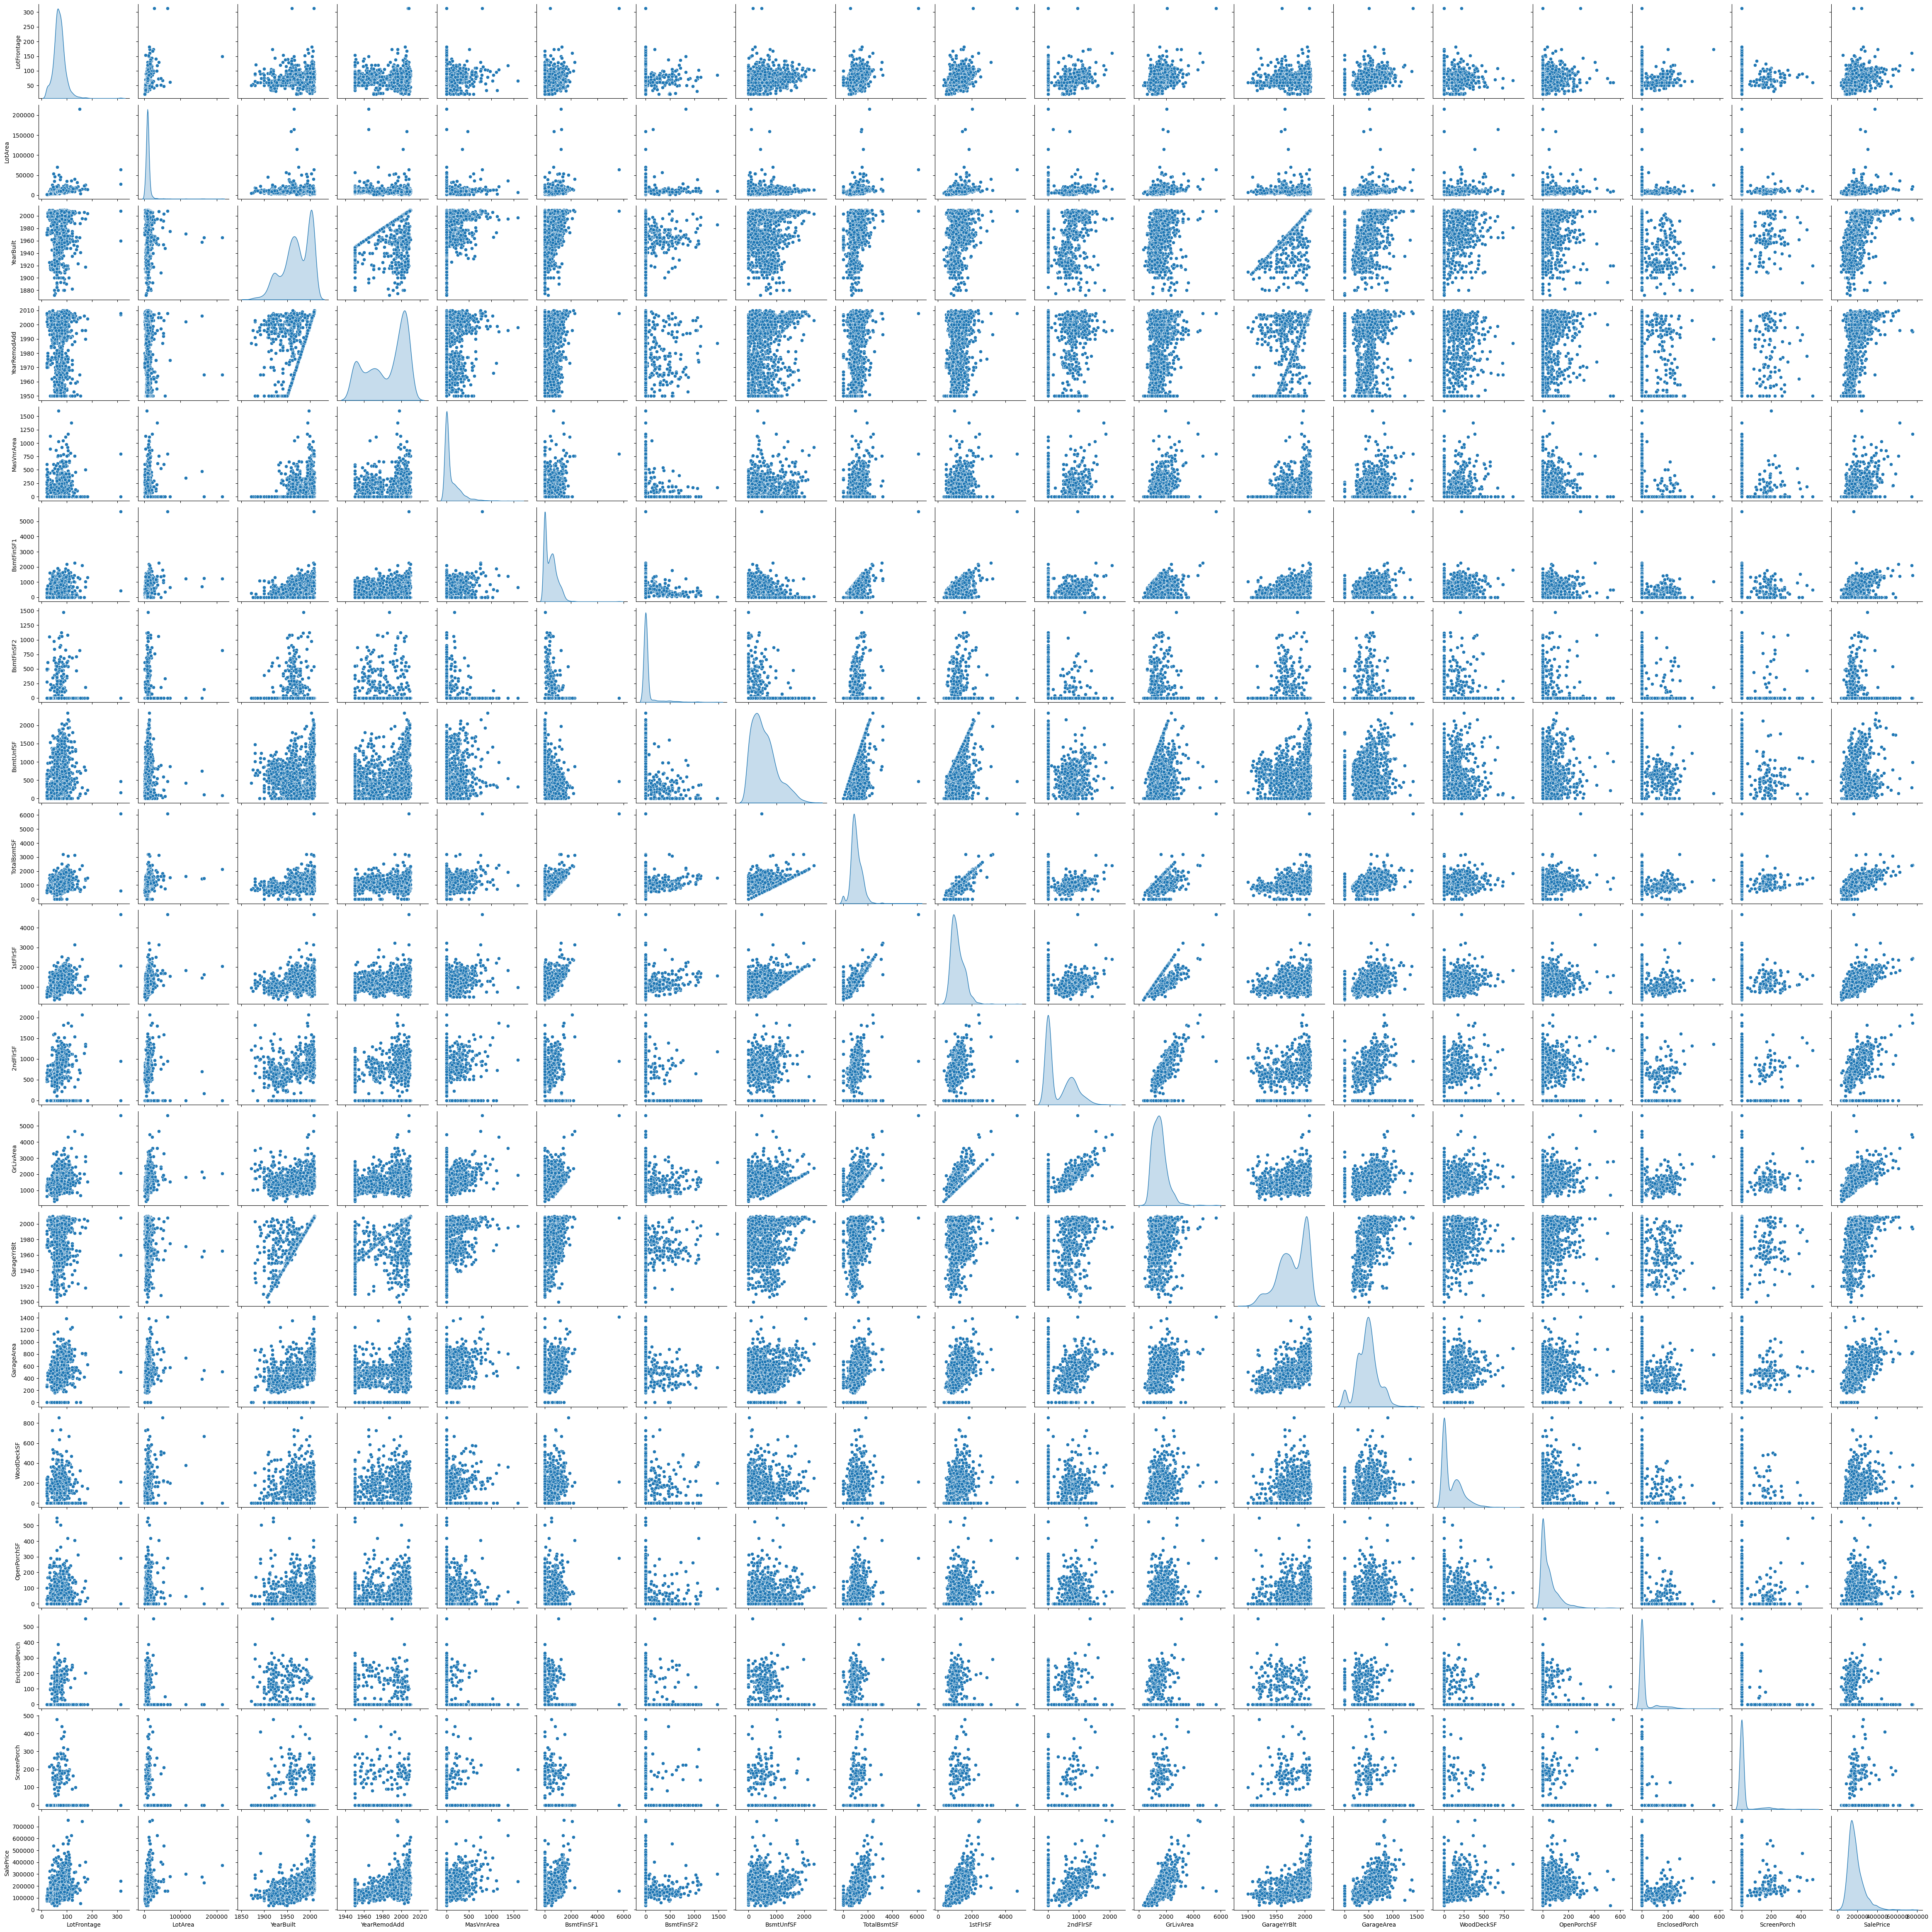

In [13]:
sns.pairplot(df[numerical_continuous], diag_kind='kde')

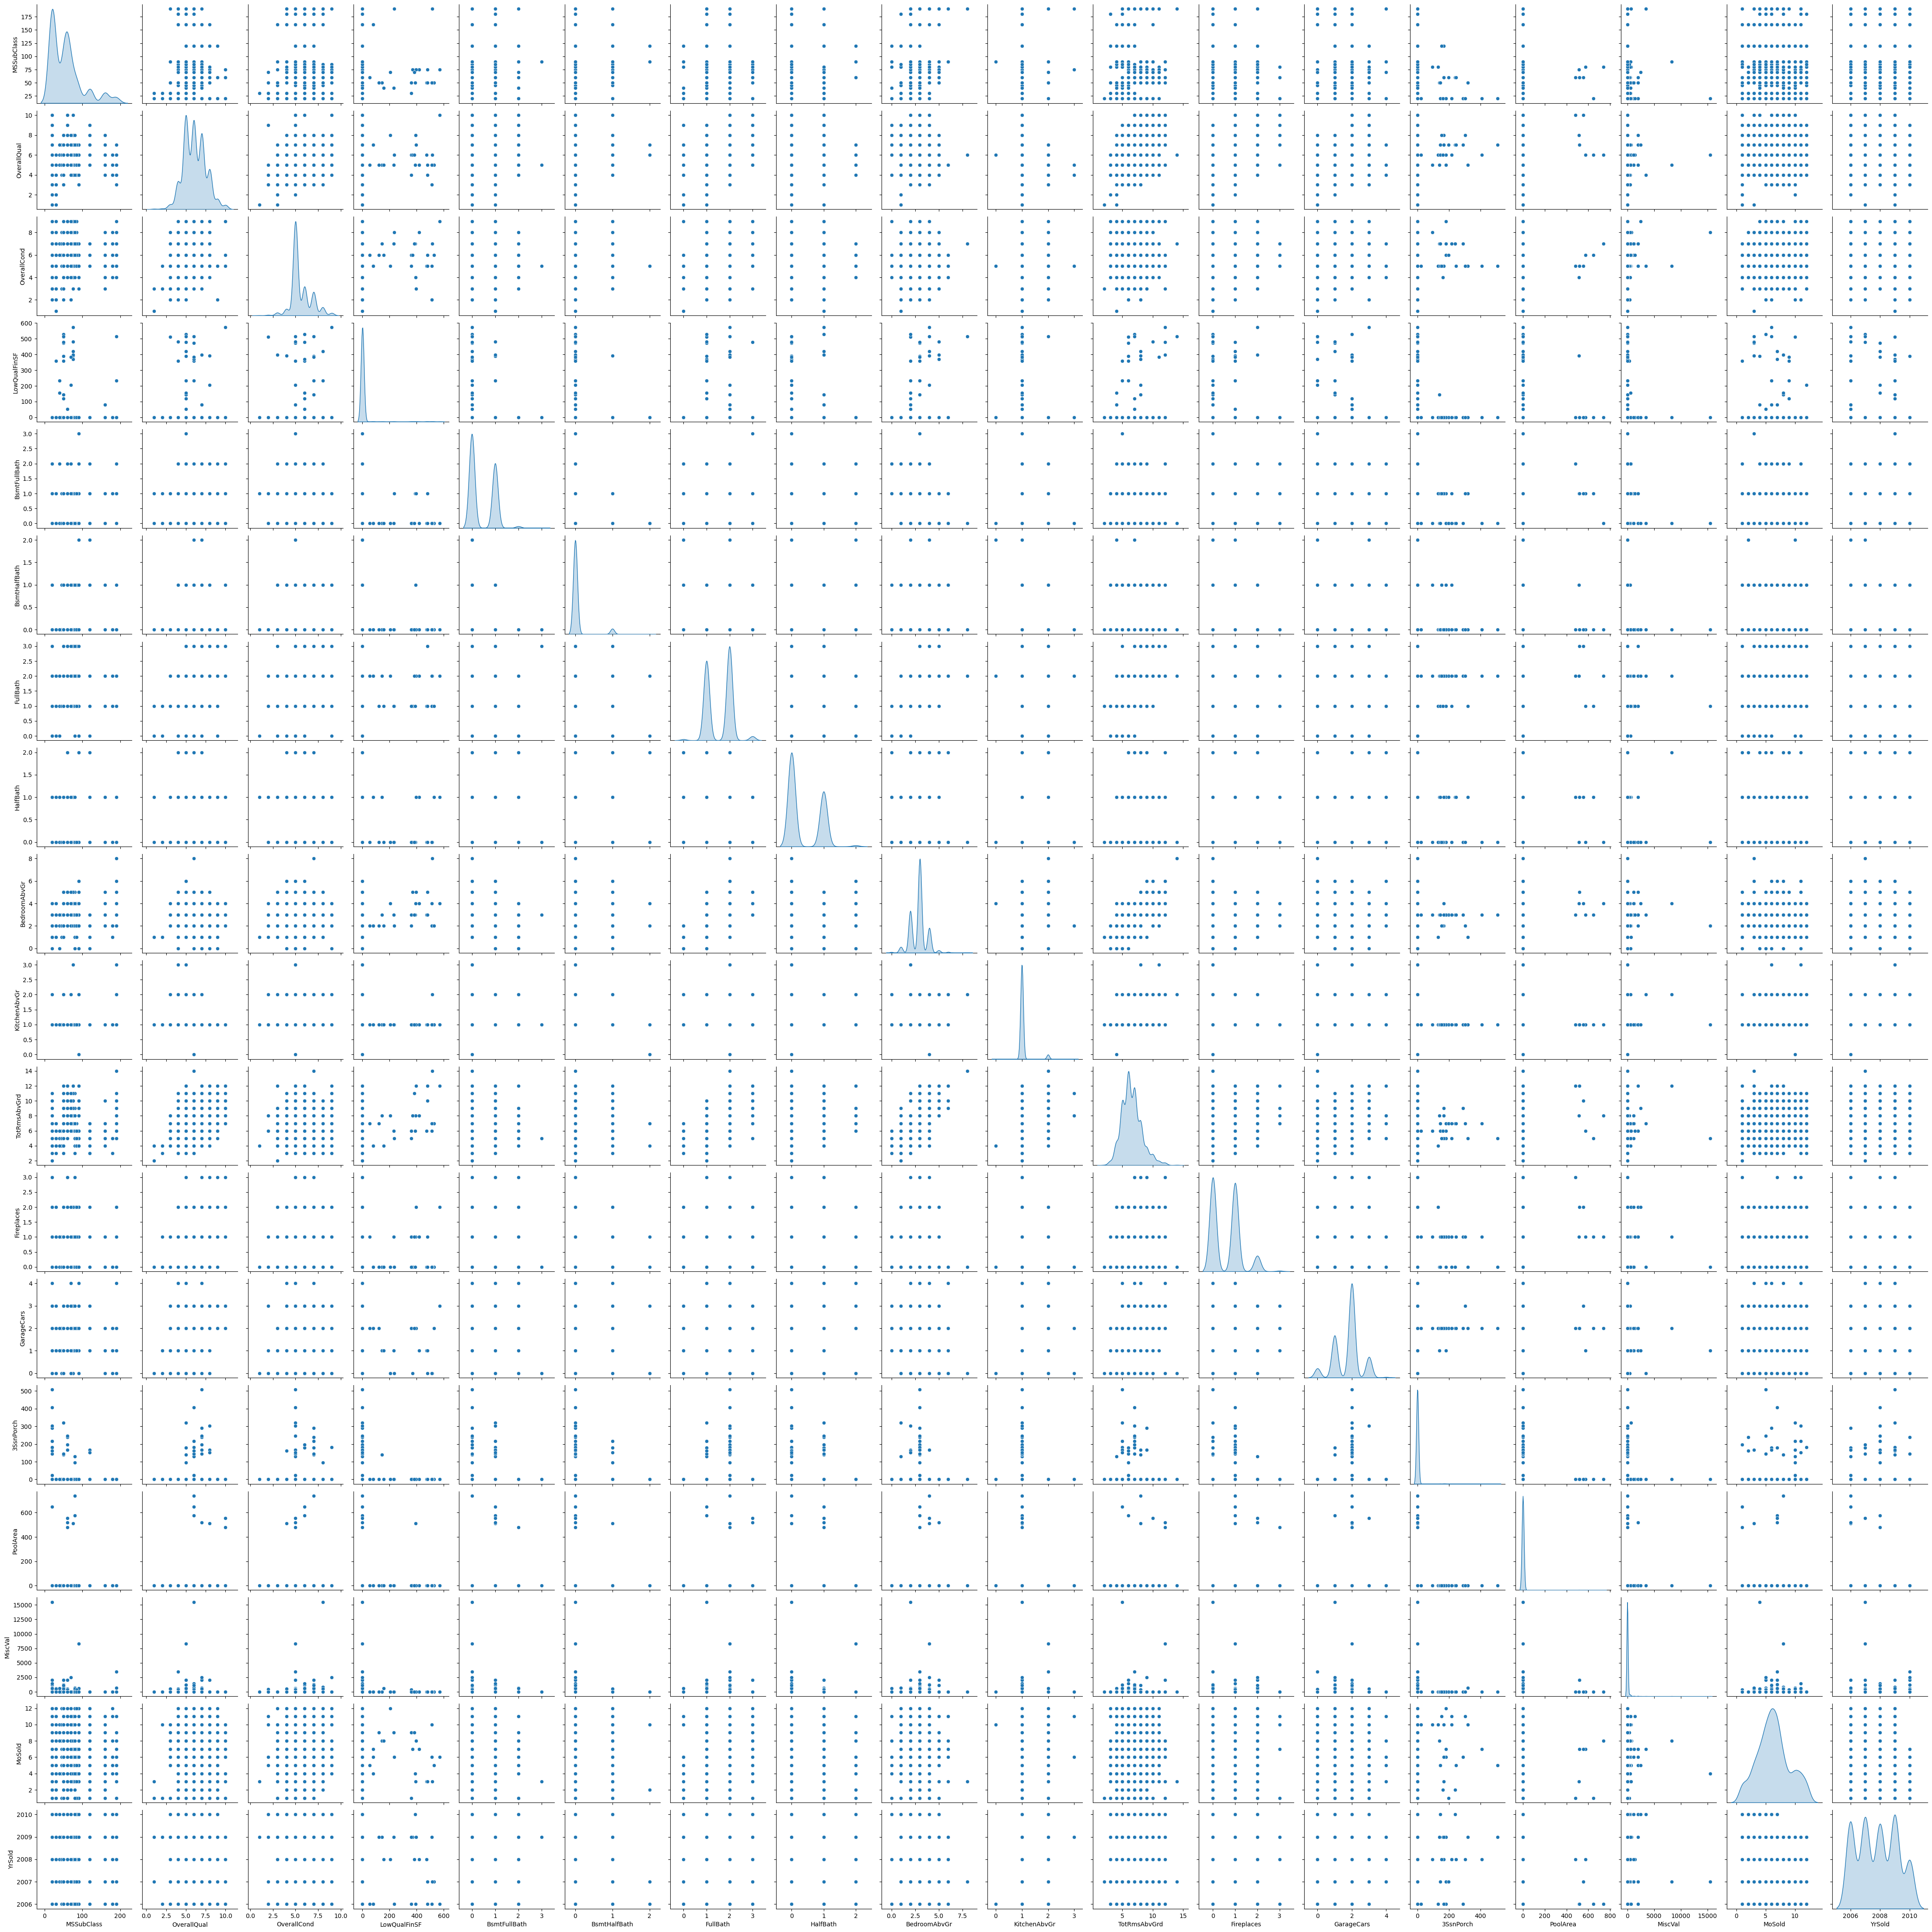

In [14]:
sns.pairplot(df[numerical_discrete], diag_kind='kde')

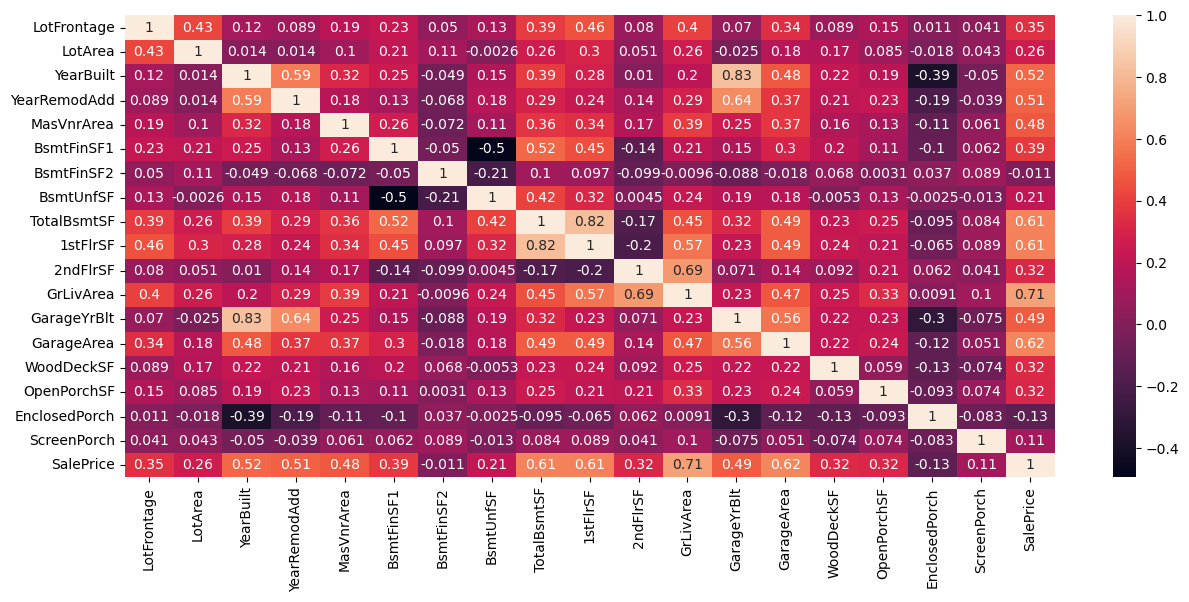

In [15]:
plt.figure(figsize=(15,6))
sns.heatmap(df[numerical_continuous].corr(), annot=True)
plt.show()

In [16]:
drop_colums = ['GarageYrBlt' , 'TotalBsmtSF']

df.drop(columns=[col for col in drop_colums if col in df.columns], inplace=True)

print("------------------------")
print(df.shape)

------------------------
(1460, 78)


In [17]:
categorical_cols = df.select_dtypes(include=[object]).columns.tolist()
categorical_cols

['MSZoning',
 'Street',
 'Alley',
 'LotShape',
 'LandContour',
 'Utilities',
 'LotConfig',
 'LandSlope',
 'Neighborhood',
 'Condition1',
 'Condition2',
 'BldgType',
 'HouseStyle',
 'RoofStyle',
 'RoofMatl',
 'Exterior1st',
 'Exterior2nd',
 'MasVnrType',
 'ExterQual',
 'ExterCond',
 'Foundation',
 'BsmtQual',
 'BsmtCond',
 'BsmtExposure',
 'BsmtFinType1',
 'BsmtFinType2',
 'Heating',
 'HeatingQC',
 'CentralAir',
 'Electrical',
 'KitchenQual',
 'Functional',
 'FireplaceQu',
 'GarageType',
 'GarageFinish',
 'GarageQual',
 'GarageCond',
 'PavedDrive',
 'PoolQC',
 'Fence',
 'MiscFeature',
 'SaleType',
 'SaleCondition']

In [18]:
#missing values

In [19]:
df['MiscFeature']= df['MiscFeature'].str.strip().str.lower()

In [20]:
df['MiscFeature'].value_counts()

MiscFeature
shed    49
gar2     2
othr     2
tenc     1
Name: count, dtype: int64

In [21]:
pd.set_option('display.max_row', None)
df.isna().sum()

MSSubClass          0
MSZoning            0
LotFrontage       259
LotArea             0
Street              0
Alley            1369
LotShape            0
LandContour         0
Utilities           0
LotConfig           0
LandSlope           0
Neighborhood        0
Condition1          0
Condition2          0
BldgType            0
HouseStyle          0
OverallQual         0
OverallCond         0
YearBuilt           0
YearRemodAdd        0
RoofStyle           0
RoofMatl            0
Exterior1st         0
Exterior2nd         0
MasVnrType        872
MasVnrArea          8
ExterQual           0
ExterCond           0
Foundation          0
BsmtQual           37
BsmtCond           37
BsmtExposure       38
BsmtFinType1       37
BsmtFinSF1          0
BsmtFinType2       38
BsmtFinSF2          0
BsmtUnfSF           0
Heating             0
HeatingQC           0
CentralAir          0
Electrical          1
1stFlrSF            0
2ndFlrSF            0
LowQualFinSF        0
GrLivArea           0
BsmtFullBa

In [22]:
pd.set_option('display.max_row', None)
df.isna().mean()*100

MSSubClass        0.000000
MSZoning          0.000000
LotFrontage      17.739726
LotArea           0.000000
Street            0.000000
Alley            93.767123
LotShape          0.000000
LandContour       0.000000
Utilities         0.000000
LotConfig         0.000000
LandSlope         0.000000
Neighborhood      0.000000
Condition1        0.000000
Condition2        0.000000
BldgType          0.000000
HouseStyle        0.000000
OverallQual       0.000000
OverallCond       0.000000
YearBuilt         0.000000
YearRemodAdd      0.000000
RoofStyle         0.000000
RoofMatl          0.000000
Exterior1st       0.000000
Exterior2nd       0.000000
MasVnrType       59.726027
MasVnrArea        0.547945
ExterQual         0.000000
ExterCond         0.000000
Foundation        0.000000
BsmtQual          2.534247
BsmtCond          2.534247
BsmtExposure      2.602740
BsmtFinType1      2.534247
BsmtFinSF1        0.000000
BsmtFinType2      2.602740
BsmtFinSF2        0.000000
BsmtUnfSF         0.000000
H

In [23]:
drop_colums = ['Alley' , 'MasVnrType', 'FireplaceQu', 'PoolQC', 'Fence', 'MiscFeature']

df.drop(columns=[col for col in drop_colums if col in df.columns], inplace=True)

print("------------------------")
print(df.shape)

------------------------
(1460, 72)


In [24]:
numerical_continuous = [col for col in numerical_continuous if col in df.columns]
numerical_discrete = [col for col in numerical_discrete if col in df.columns]
categorical_cols = [col for col in categorical_cols if col in df.columns]

In [25]:
for col in categorical_cols:
    df[col]= df[col].str.strip().str.lower()
    print(f"uniques values in {col} is {df[col].nunique()} : {df[col].unique()}")

uniques values in MSZoning is 5 : ['rl' 'rm' 'c (all)' 'fv' 'rh']
uniques values in Street is 2 : ['pave' 'grvl']
uniques values in LotShape is 4 : ['reg' 'ir1' 'ir2' 'ir3']
uniques values in LandContour is 4 : ['lvl' 'bnk' 'low' 'hls']
uniques values in Utilities is 2 : ['allpub' 'nosewa']
uniques values in LotConfig is 5 : ['inside' 'fr2' 'corner' 'culdsac' 'fr3']
uniques values in LandSlope is 3 : ['gtl' 'mod' 'sev']
uniques values in Neighborhood is 25 : ['collgcr' 'veenker' 'crawfor' 'noridge' 'mitchel' 'somerst' 'nwames'
 'oldtown' 'brkside' 'sawyer' 'nridght' 'names' 'sawyerw' 'idotrr'
 'meadowv' 'edwards' 'timber' 'gilbert' 'stonebr' 'clearcr' 'npkvill'
 'blmngtn' 'brdale' 'swisu' 'blueste']
uniques values in Condition1 is 9 : ['norm' 'feedr' 'posn' 'artery' 'rrae' 'rrnn' 'rran' 'posa' 'rrne']
uniques values in Condition2 is 8 : ['norm' 'artery' 'rrnn' 'feedr' 'posn' 'posa' 'rran' 'rrae']
uniques values in BldgType is 5 : ['1fam' '2fmcon' 'duplex' 'twnhse' 'twnhs']
uniques valu

In [26]:
from sklearn.preprocessing import OrdinalEncoder
label_encode = OrdinalEncoder()

In [27]:
from sklearn.impute import SimpleImputer

median_imputer = SimpleImputer(strategy="median")

mode_imputer = SimpleImputer(strategy="most_frequent")

from sklearn.compose import make_column_transformer

ct = make_column_transformer(

    (median_imputer, numerical_continuous),
    (mode_imputer, numerical_discrete),
    (mode_imputer, categorical_cols),
    remainder = 'passthrough'

).set_output(transform= 'pandas')

df_processed = ct.fit_transform(df)
df_processed.head()
print(df.shape)

(1460, 72)


In [28]:
df_processed.isna().sum()

simpleimputer-1__LotFrontage      0
simpleimputer-1__LotArea          0
simpleimputer-1__YearBuilt        0
simpleimputer-1__YearRemodAdd     0
simpleimputer-1__MasVnrArea       0
simpleimputer-1__BsmtFinSF1       0
simpleimputer-1__BsmtFinSF2       0
simpleimputer-1__BsmtUnfSF        0
simpleimputer-1__1stFlrSF         0
simpleimputer-1__2ndFlrSF         0
simpleimputer-1__GrLivArea        0
simpleimputer-1__GarageArea       0
simpleimputer-1__WoodDeckSF       0
simpleimputer-1__OpenPorchSF      0
simpleimputer-1__EnclosedPorch    0
simpleimputer-1__ScreenPorch      0
simpleimputer-1__SalePrice        0
simpleimputer-2__MSSubClass       0
simpleimputer-2__OverallQual      0
simpleimputer-2__OverallCond      0
simpleimputer-2__LowQualFinSF     0
simpleimputer-2__BsmtFullBath     0
simpleimputer-2__BsmtHalfBath     0
simpleimputer-2__FullBath         0
simpleimputer-2__HalfBath         0
simpleimputer-2__BedroomAbvGr     0
simpleimputer-2__KitchenAbvGr     0
simpleimputer-2__TotRmsAbvGr

In [29]:
categorical_cols_new = df_processed.select_dtypes(include=[object]).columns.tolist()
categorical_cols_new

['simpleimputer-3__MSZoning',
 'simpleimputer-3__Street',
 'simpleimputer-3__LotShape',
 'simpleimputer-3__LandContour',
 'simpleimputer-3__Utilities',
 'simpleimputer-3__LotConfig',
 'simpleimputer-3__LandSlope',
 'simpleimputer-3__Neighborhood',
 'simpleimputer-3__Condition1',
 'simpleimputer-3__Condition2',
 'simpleimputer-3__BldgType',
 'simpleimputer-3__HouseStyle',
 'simpleimputer-3__RoofStyle',
 'simpleimputer-3__RoofMatl',
 'simpleimputer-3__Exterior1st',
 'simpleimputer-3__Exterior2nd',
 'simpleimputer-3__ExterQual',
 'simpleimputer-3__ExterCond',
 'simpleimputer-3__Foundation',
 'simpleimputer-3__BsmtQual',
 'simpleimputer-3__BsmtCond',
 'simpleimputer-3__BsmtExposure',
 'simpleimputer-3__BsmtFinType1',
 'simpleimputer-3__BsmtFinType2',
 'simpleimputer-3__Heating',
 'simpleimputer-3__HeatingQC',
 'simpleimputer-3__CentralAir',
 'simpleimputer-3__Electrical',
 'simpleimputer-3__KitchenQual',
 'simpleimputer-3__Functional',
 'simpleimputer-3__GarageType',
 'simpleimputer-3__Gar

In [30]:
df_new= df_processed.copy()
df_new[categorical_cols_new] = label_encode.fit_transform(df_processed[categorical_cols_new])

In [31]:
df_new[categorical_cols_new].head()


,simpleimputer-3__MSZoning,simpleimputer-3__Street,simpleimputer-3__LotShape,simpleimputer-3__LandContour,simpleimputer-3__Utilities,simpleimputer-3__LotConfig,simpleimputer-3__LandSlope,simpleimputer-3__Neighborhood,simpleimputer-3__Condition1,simpleimputer-3__Condition2,...,simpleimputer-3__Electrical,simpleimputer-3__KitchenQual,simpleimputer-3__Functional,simpleimputer-3__GarageType,simpleimputer-3__GarageFinish,simpleimputer-3__GarageQual,simpleimputer-3__GarageCond,simpleimputer-3__PavedDrive,simpleimputer-3__SaleType,simpleimputer-3__SaleCondition
0,3.0,1.0,3.0,3.0,0.0,4.0,0.0,5.0,2.0,2.0,...,4.0,2.0,6.0,1.0,1.0,4.0,4.0,2.0,8.0,4.0
1,3.0,1.0,3.0,3.0,0.0,2.0,0.0,24.0,1.0,2.0,...,4.0,3.0,6.0,1.0,1.0,4.0,4.0,2.0,8.0,4.0
2,3.0,1.0,0.0,3.0,0.0,4.0,0.0,5.0,2.0,2.0,...,4.0,2.0,6.0,1.0,1.0,4.0,4.0,2.0,8.0,4.0
3,3.0,1.0,0.0,3.0,0.0,0.0,0.0,6.0,2.0,2.0,...,4.0,2.0,6.0,5.0,2.0,4.0,4.0,2.0,8.0,0.0
4,3.0,1.0,0.0,3.0,0.0,2.0,0.0,13.0,2.0,2.0,...,4.0,2.0,6.0,1.0,1.0,4.0,4.0,2.0,8.0,4.0


In [32]:
df_new.duplicated().sum()

np.int64(0)

In [33]:
df_new.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 72 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   simpleimputer-1__LotFrontage    1460 non-null   float64
 1   simpleimputer-1__LotArea        1460 non-null   float64
 2   simpleimputer-1__YearBuilt      1460 non-null   float64
 3   simpleimputer-1__YearRemodAdd   1460 non-null   float64
 4   simpleimputer-1__MasVnrArea     1460 non-null   float64
 5   simpleimputer-1__BsmtFinSF1     1460 non-null   float64
 6   simpleimputer-1__BsmtFinSF2     1460 non-null   float64
 7   simpleimputer-1__BsmtUnfSF      1460 non-null   float64
 8   simpleimputer-1__1stFlrSF       1460 non-null   float64
 9   simpleimputer-1__2ndFlrSF       1460 non-null   float64
 10  simpleimputer-1__GrLivArea      1460 non-null   float64
 11  simpleimputer-1__GarageArea     1460 non-null   float64
 12  simpleimputer-1__WoodDeckSF     14

In [34]:
numerical_cols_iqr = df_new.select_dtypes(include=['int64', 'float64']).columns.tolist()

def detect_outliers_iqr(data, feature):
    Q1 = data[feature].quantile(0.25)
    Q3 = data[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[feature] < lower_bound) | (data[feature] > upper_bound)]
    return outliers

# 3. المرور وطباعة النتائج
for col in numerical_cols_iqr:
    outliers = detect_outliers_iqr(df_new, col)
    print(f"{col}: {len(outliers)/len_col *100:.2f} outliers")

simpleimputer-1__LotFrontage: 15.99 outliers
simpleimputer-1__LotArea: 10.41 outliers
simpleimputer-1__YearBuilt: 1.06 outliers
simpleimputer-1__YearRemodAdd: 0.00 outliers
simpleimputer-1__MasVnrArea: 14.78 outliers
simpleimputer-1__BsmtFinSF1: 1.06 outliers
simpleimputer-1__BsmtFinSF2: 25.19 outliers
simpleimputer-1__BsmtUnfSF: 4.37 outliers
simpleimputer-1__1stFlrSF: 3.02 outliers
simpleimputer-1__2ndFlrSF: 0.30 outliers
simpleimputer-1__GrLivArea: 4.68 outliers
simpleimputer-1__GarageArea: 3.17 outliers
simpleimputer-1__WoodDeckSF: 4.83 outliers
simpleimputer-1__OpenPorchSF: 11.61 outliers
simpleimputer-1__EnclosedPorch: 31.37 outliers
simpleimputer-1__ScreenPorch: 17.50 outliers
simpleimputer-1__SalePrice: 9.20 outliers
simpleimputer-2__MSSubClass: 15.54 outliers
simpleimputer-2__OverallQual: 0.30 outliers
simpleimputer-2__OverallCond: 18.85 outliers
simpleimputer-2__LowQualFinSF: 3.92 outliers
simpleimputer-2__BsmtFullBath: 0.15 outliers
simpleimputer-2__BsmtHalfBath: 12.37 outli

In [35]:
columns_to_drop = [
    'simpleimputer-1__BsmtFinSF2',
    'simpleimputer-1__EnclosedPorch',
    'simpleimputer-3__Condition1',
    'simpleimputer-3__BldgType',
    'simpleimputer-3__RoofStyle',
    'simpleimputer-3__ExterCond',
    'simpleimputer-3__BsmtExposure',
    'simpleimputer-3__BsmtFinType2',
    'simpleimputer-3__SaleType',
    'simpleimputer-3__SaleCondition',
    'simpleimputer-3__MSZoning',
    'simpleimputer-3__LandContour'
]

df_new = df_new.drop(columns=columns_to_drop, errors='ignore')

print("df_new:", df_new.shape[1])

df_new: 60


In [36]:
for col in numerical_cols_iqr:
    if col in df_new.columns:
        Q1 = df_new[col].quantile(0.25)
        Q3 = df_new[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        df_new[col] = df_new[col].clip(lower=lower_bound, upper=upper_bound)



In [37]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

target_col = 'simpleimputer-1__SalePrice' 
X = df_new.drop(columns=[target_col], errors='ignore')
y = df_new[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


--- Top 10 Important Features ---
                          Feature  Importance
15   simpleimputer-2__OverallQual    0.592596
9      simpleimputer-1__GrLivArea    0.123862
7       simpleimputer-1__1stFlrSF    0.035493
5     simpleimputer-1__BsmtFinSF1    0.030970
26    simpleimputer-2__GarageCars    0.025725
10    simpleimputer-1__GarageArea    0.024539
2      simpleimputer-1__YearBuilt    0.021419
1        simpleimputer-1__LotArea    0.017185
37  simpleimputer-3__Neighborhood    0.010320
3   simpleimputer-1__YearRemodAdd    0.010313


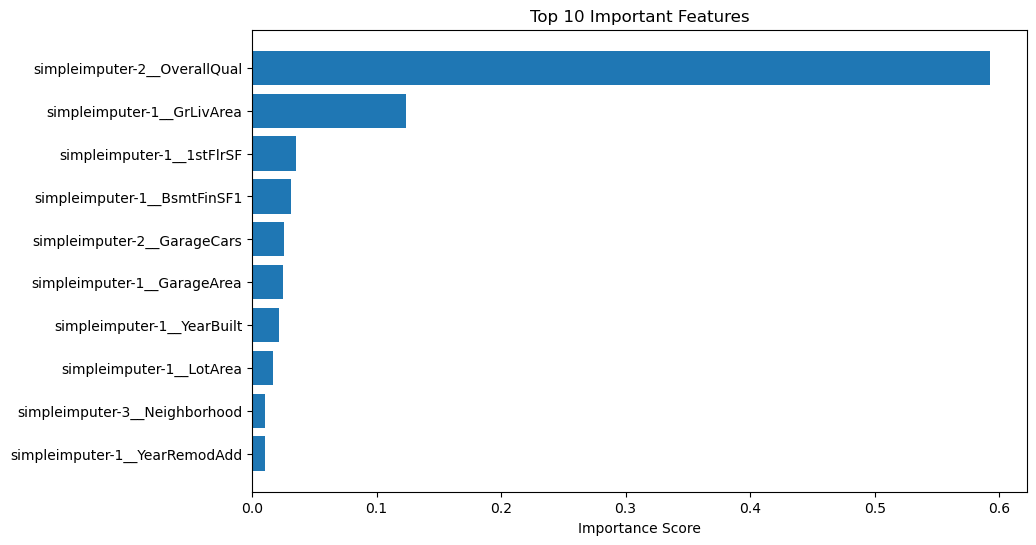

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train_scaled, y_train)

importances = rf_model.feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print("--- Top 10 Important Features ---")
print(feature_importance_df.head(10))

plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'].head(10)[::-1], feature_importance_df['Importance'].head(10)[::-1])
plt.xlabel("Importance Score")
plt.title("Top 10 Important Features")
plt.show()

In [44]:
from xgboost import XGBRegressor
from sklearn.metrics import r2_score

xgb_tuned = XGBRegressor(
    n_estimators=150,
    learning_rate=0.05,    
    max_depth=3,            
    subsample=0.8,           
    colsample_bytree=0.8,    
    random_state=42
)

xgb_tuned.fit(X_train_scaled, y_train)

train_pred_tuned = xgb_tuned.predict(X_train_scaled)
test_pred_tuned = xgb_tuned.predict(X_test_scaled)

print(f"XGBoost Tuned - Train R2: {r2_score(y_train, train_pred_tuned):.4f}")
print(f"XGBoost Tuned - Test R2: {r2_score(y_test, test_pred_tuned):.4f}")
print(f"(Gap): {abs(r2_score(y_train, train_pred_tuned) - r2_score(y_test, test_pred_tuned)):.4f}")

XGBoost Tuned - Train R2: 0.9489
XGBoost Tuned - Test R2: 0.9192
(Gap): 0.0297
